In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso

#Create a true model

In [2]:
# Create a  true model with 5 (out of 50) non-zero coefficients
np.random.seed(42) # Set seed for reproducibility

p = 50 # Number of features (high-dimensional setting)

beta = np.zeros(p)
beta[:5] = [5, -3, 2, 0.5, -1]  # First 5 non-zero coefficients

## Test set

In [3]:
n_test = 1000
sigma = 5 # standard deviation of noise
irreducible_error = sigma**2
X_test = np.random.randn(n_test, p) # Data distributed normally
f_test = X_test @ beta #True function
epsilon_test = np.random.randn(n_test) * sigma # Noise
y_test = f_test + epsilon_test # Function with noise

In [4]:
# Define the fictional regression problem
def mse(beta_1, beta_2, X1, X2, y):
    """Calculate MSE for given beta_0, beta_1."""
    y_pred = beta_1 * X1 + beta_2 * X2
    return np.mean((y - y_pred) ** 2)

##Regularization grid

In [5]:
lambdas = np.logspace(-3, 4, 30) # Parameters in log scale to show full spectrum of

# Main experiment

In [6]:
def run_experiment(model_type):
    bias2_list = []
    var_list = []
    mse_list = []

    n_train = 100
    n_runs = 100

    #Loop over different lamba values
    for lam in lambdas:
        predictions = []

        for _ in range(n_runs):
            # Generate training data
            X_train = np.random.randn(n_train, p)
            epsilon = np.random.randn(n_train) * sigma
            y_train = X_train @ beta + epsilon

            # Fit model
            if model_type == "ridge":
                model = Ridge(alpha=lam)
            if model_type == "lasso":
                model = Lasso(alpha=lam, max_iter=10000)

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            predictions.append(y_pred)

        predictions = np.array(predictions)

        # Mean prediction
        mean_pred = predictions.mean(axis=0)

        # Bias² (vs true function)
        bias2 = np.mean((mean_pred - f_test) ** 2)

        # Variance
        variance = np.mean(np.var(predictions, axis=0))

        # MSE (vs function with noise)
        mse = np.mean((predictions - y_test) ** 2)

        bias2_list.append(bias2)
        var_list.append(variance)
        mse_list.append(mse)

    return bias2_list, var_list, mse_list

# Run experiment

In [7]:
ridge_bias2, ridge_var, ridge_mse = run_experiment("ridge")
lasso_bias2, lasso_var, lasso_mse = run_experiment("lasso")

#Plots

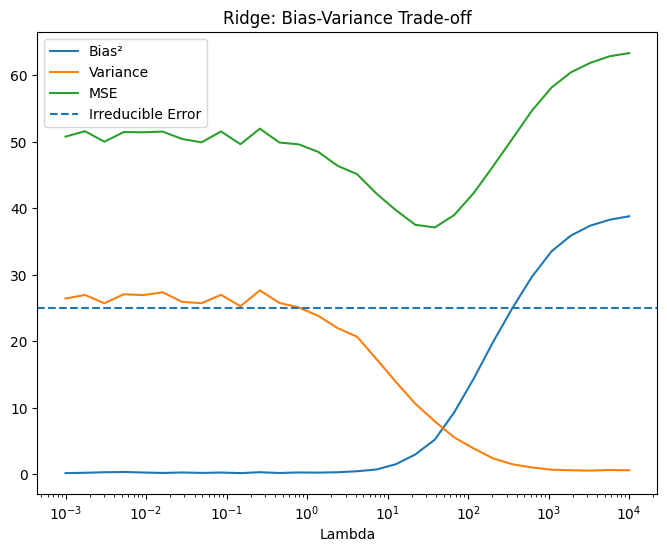

In [8]:
plt.figure(figsize=(8,6))
plt.plot(lambdas, ridge_bias2, label="Bias²")
plt.plot(lambdas, ridge_var, label="Variance")
plt.plot(lambdas, ridge_mse, label="MSE")
plt.axhline(irreducible_error, linestyle='--', label='Irreducible Error')
plt.xscale("log")
plt.title("Ridge: Bias-Variance Trade-off")
plt.xlabel("Lambda")
plt.legend()
plt.show()

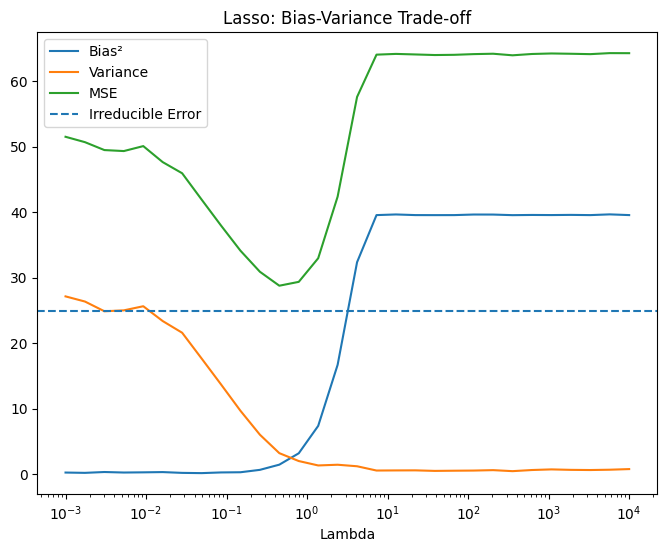

In [9]:
plt.figure(figsize=(8,6))
plt.plot(lambdas, lasso_bias2, label="Bias²")
plt.plot(lambdas, lasso_var, label="Variance")
plt.plot(lambdas, lasso_mse, label="MSE")
plt.axhline(irreducible_error, linestyle='--', label='Irreducible Error')

plt.xscale("log")
plt.title("Lasso: Bias-Variance Trade-off")
plt.xlabel("Lambda")
plt.legend()
plt.show()

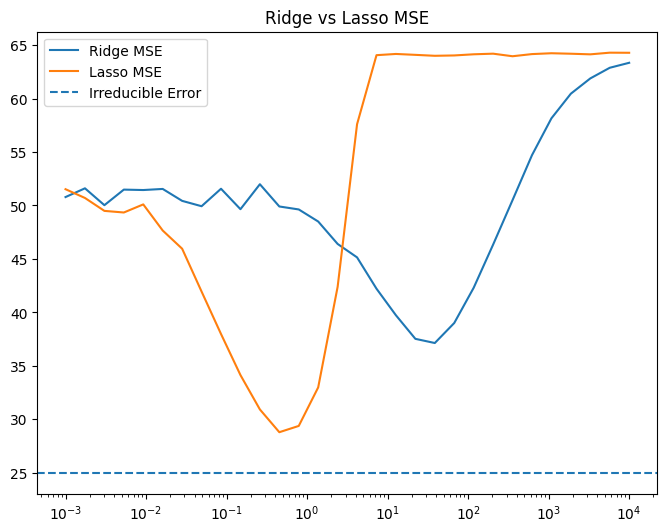

In [10]:
plt.figure(figsize=(8,6))
plt.plot(lambdas, ridge_mse, label="Ridge MSE")
plt.plot(lambdas, lasso_mse, label="Lasso MSE")
plt.axhline(irreducible_error, linestyle='--', label='Irreducible Error')

plt.xscale("log")
plt.legend()
plt.title("Ridge vs Lasso MSE")
plt.show()

# Results and Interpretation

The empirical results confirm the theoretical bias–variance trade-off.

From the experiments:

- **Lasso achieved the lowest MSE of approximately 30 at $ \lambda \approx 1 $**  
- **Ridge achieved its minimum MSE of approximately 40 at $ \lambda \approx 40$**  

# MSE Decomposition: Bias, Variance, and Irreducible Error

We consider a regression setting where the data is generated as:


$y = f(x) + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma^2)$

Let $ \hat{f}(x) $ be the model learned from training data. The goal is to analyze the **expected prediction error**:

$\mathbb{E}\big[(y - \hat{f}(x))^2\big]$

---

## Decomposition

This error can be decomposed into three components:

$
\mathbb{E}[(y - \hat f(x))^2] = \underbrace{\text{Bias}^2}_{\text{systematic error}} + \underbrace{\text{Variance}}_{\text{sensitivity to data}} + \underbrace{\sigma^2}_{\text{irreducible error}}
$

---

## 1. Bias

$
\text{Bias}(x) = \mathbb{E}[\hat f(x)] - f(x)
$

- Measures how far the **average prediction** is from the true function  
- High bias → model is too simple (underfitting)  
- Caused by strong regularization  

In this experiment:
- Bias increases as $ \lambda $ increases

---

## 2. Variance

$\text{Var}(x) = \mathbb{E}\big[(\hat f(x) - \mathbb{E}[\hat f(x)])^2\big]$

- Measures how much predictions vary across different training datasets  
- High variance → model is unstable (overfitting)  

In this experiment:
- Variance decreases as $\lambda$ increases

---

## 3. Irreducible Error


$\sigma^2 = \text{Var}(\epsilon)$

- Comes from noise in the data  
- Cannot be reduced by any model  
- Sets a lower bound on MSE

---

## Key Insight

- Bias and variance depend on the model  
- Irreducible error is constant  

Thus, model selection focuses on minimizing:

$\text{MSE} = \text{Bias}^2 + \text{Variance}$

---

# Bias–Variance Trade-off and Regularization

Regularization (controlled by $\lambda $) affects model complexity:

---

## Small $ \lambda $ (weak regularization)

- Model is very flexible  
- Fits training data closely (including noise)  
- Low bias, high variance  

 Overfitting region  

---

## Large $ \lambda $ (strong regularization)

- Model is heavily constrained  
- Coefficients shrink toward zero  
- High bias, low variance  

 Underfitting region  

---

## Optimal $ \lambda $

- Balanced flexibility  
- Reduced variance without excessive bias  

 This is where MSE is minimized  

---

## Why does an optimal point exist?

The total error is:

$\text{MSE} = \text{Bias}^2 + \text{Variance} + \sigma^2$

- As $ \lambda $ increases:
  - Bias increases  
  - Variance decreases  

These effects move in opposite directions, producing a **U-shaped curve** for MSE.

- Initially: variance reduction dominates → MSE decreases  
- Later: bias dominates → MSE increases  

 Therefore, an optimal $ \lambda $ exists where MSE is minimized.

---

## Final Takeaway

The best model is not the most flexible one, but the one that achieves the optimal balance between bias and variance.

#  Ridge vs  Lasso: Bias–Variance Trade-off Analysis

Both Ridge and Lasso regression introduce regularization to control model complexity and improve generalization. However, they differ significantly in how they affect bias, variance, and model structure.

---

##  Bias–Variance Trade-off

###  Ridge Regression (L2 regularization)

Ridge regression uses the $\ell_2$ norm as the penalty:
$$
\|\beta\|_2^2 = \sum_{j=1}^p \beta_j^2.
$$
The penalized objective function for ridge regression is:
$$
\min_\beta \frac{1}{2} \|y - X\beta\|_2^2 + \lambda \|\beta\|_2^2.
$$ with $\lambda > 0$ controlling the penalty strength.
- Shrinks coefficients **continuously toward zero**
- Does **not eliminate features**
- Produces **stable, smooth solutions**

**Effect on bias–variance:**
- Bias increases gradually as $ \lambda $ increases  
- Variance decreases significantly  
- Typically achieves a **good balance** when many features contribute small effects  

Ridge reduces variance effectively while introducing only moderate bias.

---

###  Lasso Regression (L1 regularization)

The Lasso (Least Absolute Shrinkage and Selection Operator) method uses the $\ell_1$ norm as the penalty term.

The penalized objective function for Lasso regression is:
$$
\min_\beta \frac{1}{2} \|y - X\beta\|_2^2 + \lambda \|\beta\|_1,
$$
with
$$
\|\beta\|_1 = \sum_{j=1}^p |\beta_j|.
$$
- Shrinks coefficients and can set some **exactly to zero**
- Performs **implicit feature selection**
- Produces **sparse models**

**Effect on bias–variance:**
- Bias increases more aggressively than Ridge  
- Variance decreases strongly (due to sparsity)  
- Can oversimplify if too many features are removed  

 Lasso trades higher bias for stronger variance reduction.

---

##  When does each method perform better?

###  Lasso performs better when:

- The true model is **sparse** (only a few relevant features)  
- Feature selection is important  
- Interpretability matters  

 In this experiment:
- Only 5 out of 50 coefficients are non-zero  
- Therefore, **Lasso is well-aligned with the true structure**

---

###  Ridge performs better when:

- Many features have **small but non-zero effects**  
- Features are **highly correlated (multicollinearity)**  
- Stability is more important than sparsity  

 Ridge distributes weights across correlated features instead of selecting one arbitrarily.

---

## Effect of Multicollinearity

- **Ridge** handles multicollinearity well:
  - Shares weights across correlated variables  
  - Produces stable solutions  

- **Lasso** struggles with multicollinearity:
  - Often selects **one feature and ignores others**  
  - Can be unstable depending on the dataset  

---

## Final Insight

- Ridge is a **shrinkage method** → keeps all features, reduces variance smoothly  
- Lasso is a **selection method** → simplifies the model by removing features  

 The choice depends on the underlying data structure:

- Sparse true model → **Lasso preferred**  
- Dense or correlated features → **Ridge preferred**